In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import torch.optim as optim
import pandas as pd
from tqdm import tqdm


c:\Users\KRISH\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import json
with open(r"D:\multimodal-clinical-ai\multimodal-clinical-ai\data\metadata\label_map.json", "r") as f:
    LABEL2ID = json.load(f)
ID2LABEL={v:k for k,v in LABEL2ID.items()}
NUM_CLASSES = len(LABEL2ID)

In [3]:
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


In [4]:
class TextOnlyDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=256):
        self.df = pd.read_csv(csv_file)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        encoding = self.tokenizer(
            row["findings"],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)
        label = torch.tensor(LABEL2ID[row["label"]], dtype=torch.long)

        return input_ids, attention_mask, label


In [5]:
CSV_PATH = "D:\\multimodal-clinical-ai\\multimodal-clinical-ai\\data\\metadata\\patient_index.csv"

dataset = TextOnlyDataset(CSV_PATH, tokenizer)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)

print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))


Train samples: 24498
Val samples: 6125


In [6]:
class ClinicalBERTClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        x = self.dropout(cls_embedding)
        return self.classifier(x)


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ClinicalBERTClassifier(NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-5)


In [8]:
print(model)

ClinicalBERTClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

In [9]:
# Freeze everything first
for param in model.bert.parameters():
    param.requires_grad = False

# Unfreeze last 2 layers
for layer in model.bert.encoder.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True


In [10]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for input_ids, attention_mask, labels in tqdm(loader):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    return running_loss / len(loader), correct / total


def validate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for input_ids, attention_mask, labels in loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(input_ids, attention_mask)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


In [11]:
EPOCHS = 4

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_acc = validate(model, val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Train Acc : {train_acc:.4f}")
    print(f"  Val Acc   : {val_acc:.4f}")


100%|██████████| 1532/1532 [09:05<00:00,  2.81it/s]



Epoch 1/4
  Train Loss: 1.3842
  Train Acc : 0.4602
  Val Acc   : 0.5687


100%|██████████| 1532/1532 [08:03<00:00,  3.17it/s]



Epoch 2/4
  Train Loss: 1.1042
  Train Acc : 0.5861
  Val Acc   : 0.6209


100%|██████████| 1532/1532 [08:03<00:00,  3.17it/s]



Epoch 3/4
  Train Loss: 1.0407
  Train Acc : 0.6127
  Val Acc   : 0.6250


100%|██████████| 1532/1532 [08:02<00:00,  3.17it/s]



Epoch 4/4
  Train Loss: 1.0012
  Train Acc : 0.6284
  Val Acc   : 0.6421


In [12]:
torch.save(
    {
        "model_state": model.state_dict(),
        "label_map": LABEL2ID
    },
    r"D:\multimodal-clinical-ai\multimodal-clinical-ai\checkpoints\text_only_baseline.pt"
)

print("✅ Text-only baseline saved.")


✅ Text-only baseline saved.


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


In [14]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for input_ids, attention_mask, labels in val_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        outputs = model(input_ids, attention_mask)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [15]:
print(len(all_preds), len(all_labels))


6125 6125


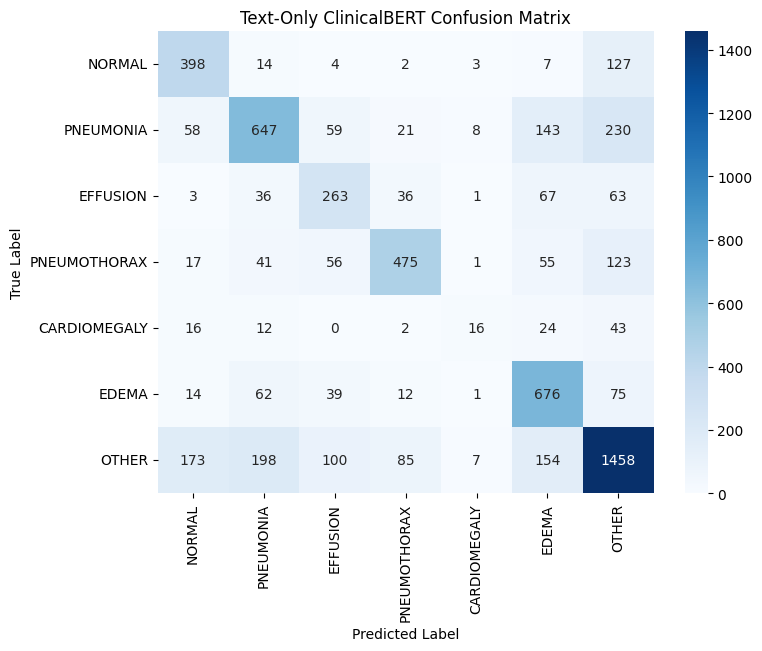

In [16]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ID2LABEL.values(),
    yticklabels=ID2LABEL.values()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Text-Only ClinicalBERT Confusion Matrix")
plt.show()


In [17]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=list(ID2LABEL.values()),
        digits=4
    )
)


              precision    recall  f1-score   support

      NORMAL     0.5862    0.7171    0.6451       555
   PNEUMONIA     0.6406    0.5549    0.5947      1166
    EFFUSION     0.5048    0.5608    0.5313       469
PNEUMOTHORAX     0.7504    0.6185    0.6781       768
CARDIOMEGALY     0.4324    0.1416    0.2133       113
       EDEMA     0.6004    0.7691    0.6743       879
       OTHER     0.6881    0.6703    0.6791      2175

    accuracy                         0.6421      6125
   macro avg     0.6004    0.5760    0.5737      6125
weighted avg     0.6463    0.6421    0.6392      6125



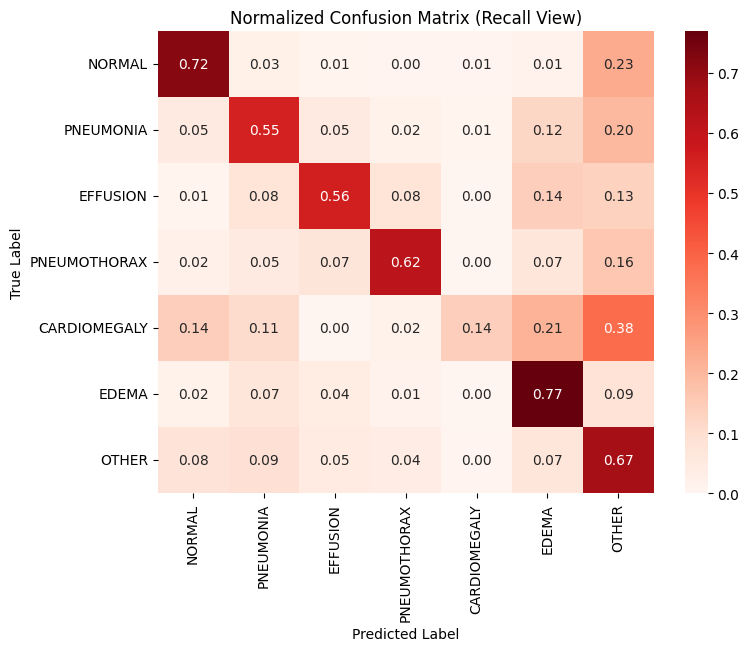

In [18]:
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    xticklabels=ID2LABEL.values(),
    yticklabels=ID2LABEL.values()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (Recall View)")
plt.show()
